In [205]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.impute import SimpleImputer

# Exploratory Data Analysis and Data Cleaning

In [206]:
# read the data
dataset=pd.read_csv('heart.csv')
# dataset = pd.read_csv(r"D:\Downloads\Machine_Learning_Projects\heart_disease_prediction")


In [207]:
dataset.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0


In [208]:
dataset.shape

(1025, 14)

In [209]:
# check fro missing values
(dataset.isnull().sum().sort_values(ascending=False)/dataset.shape[0])*100
# dataset.isnull().sum().sort_values(ascending=False)

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64

In [210]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [211]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [212]:
# now check target column
dataset['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [213]:
dataset['target'].unique()

array([0, 1])

In [214]:
dataset['target'].nunique()

2

In [215]:
# now check data types
dataset.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [216]:
# pd.set_option('display.max_columns',26)

In [217]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Preprocessing

**` Now separate features and target(output)`**

In [218]:
x=dataset.drop(columns='target')

In [219]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


**`1-------> hd(heart disease)`**
**`0------->nothd (no heart disease)`**



In [220]:
# y=dataset['classification']
y=dataset.iloc[:,-1]

In [221]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

**`Train test split`**



In [222]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,stratify=y,test_size=.20)

In [223]:
x.shape,x_train.shape,x_test.shape

((1025, 13), (820, 13), (205, 13))

In [224]:
y.shape,y_train.shape,y_test.shape

((1025,), (820,), (205,))

**`Now make transformer for cat and numerical features`**

In [225]:
# Auto feature selection
num_features = x.columns.tolist()
print(num_features)

# Pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features)
])

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


# Model training and Evaluation

In [226]:
# now combine preprocessor and model to get final pipeline
pipeline=Pipeline([
    ('preprocessor',preprocessor),
  ('model',RandomForestClassifier(random_state=42))
])

In [227]:
# now train the model
pipeline.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [228]:
pipeline.score(x_train,y_train)*100,pipeline.score(x_test,y_test)*100

(100.0, 100.0)

**`Now evaluate the model`**

In [229]:
y_pred=pipeline.predict(x_test);

In [230]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [231]:
# print confusion matrix to analyse
cm=confusion_matrix(y_test,y_pred)
print(cm)
# sns.heatmap(cm, annot=True,cmap='Blues',square=True,linecolor='black',linewidth=2,cbar=False)
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.title("Confusion Matrix")
# plt.show()

[[100   0]
 [  0 105]]


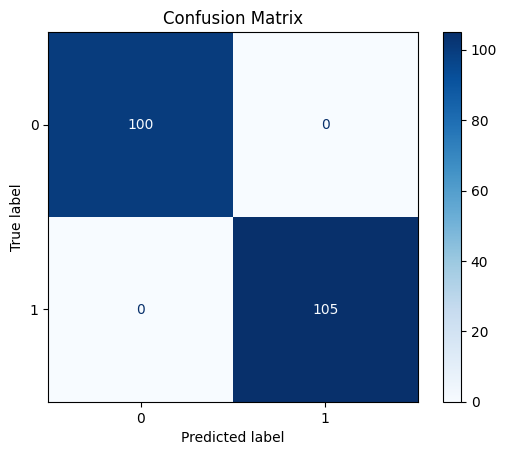

In [232]:
# display confusion

ConfusionMatrixDisplay.from_estimator(pipeline,x_test,y_test,cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [233]:
model=RandomForestClassifier(random_state=42);


In [234]:
print(f"The accuracy_score of {model} = ",accuracy_score(y_test,y_pred)*100)
print(f"\nThe precision_score of {model} = ",precision_score(y_test,y_pred)*100)
print(f"\nThe recall_score of {model} = ",recall_score(y_test,y_pred)*100)
print(f"\nThe f1_score of {model} = ",f1_score(y_test,y_pred)*100)
print(f"\nThe cross_val_score of {model} = ",cross_val_score(pipeline,x,y)*100)
print(f"\nThe mean cross_val_score of {model} = ",cross_val_score(pipeline,x,y).mean()*100)

The accuracy_score of RandomForestClassifier(random_state=42) =  100.0

The precision_score of RandomForestClassifier(random_state=42) =  100.0

The recall_score of RandomForestClassifier(random_state=42) =  100.0

The f1_score of RandomForestClassifier(random_state=42) =  100.0

The cross_val_score of RandomForestClassifier(random_state=42) =  [100.         100.         100.         100.          98.53658537]

The mean cross_val_score of RandomForestClassifier(random_state=42) =  99.70731707317073


**`So the mean accuracy of model is 99%`**

In [235]:
# # preprocess x and then check missing value
# x_filled=pipeline.named_steps['preprocessor'].fit_transform(x)
# print(pd.DataFrame(x_filled).isnull().sum().sum())
# print(pd.DataFrame(x_filled).isnull().sum())

In [236]:
from sklearn.compose import make_column_selector

# Get feature names after transformation
feature_names=pipeline.named_steps['preprocessor'].get_feature_names_out()

print("Number of final features:", len(feature_names))
print("Feature names:", feature_names)


Number of final features: 13
Feature names: ['num__age' 'num__sex' 'num__cp' 'num__trestbps' 'num__chol' 'num__fbs'
 'num__restecg' 'num__thalach' 'num__exang' 'num__oldpeak' 'num__slope'
 'num__ca' 'num__thal']


# Make Predictive system

In [237]:
import pandas as pd

# Your input (without target)
user_input = (34,0,1,118,210,0,1,192,0,0.7,2,0,2)

# Convert to DataFrame
user_input_df = pd.DataFrame([user_input], columns=x.columns)

# Prediction
prediction = pipeline.predict(user_input_df)
prob = pipeline.predict_proba(user_input_df)[0][1]

# Output
if prediction[0] == 1:
    print(f"🚨 Patient has Heart Disease.")
else:
    print(f"✅ Patient has no Heart Disease.")

🚨 Patient has Heart Disease.


**`Now save the model`**

In [238]:
import joblib

In [239]:
# save model and feature names
heart_bundle={
    "pipeline":pipeline,
    "features_names":x.columns.to_list()
}
joblib.dump(heart_bundle,"heart_model_bundle.joblib")

['heart_model_bundle.joblib']